In [1]:
import pandas as pd

In [2]:
# Good resource for TF - target genes: https://www.grnpedia.org/trrust/key_regulator/015fc0d93c.php

In [3]:

df_Adipocytes_Brown = pd.read_csv('../predictions/gene_scores/gene_scores_Adipocytes_Brown_8W.csv')


In [4]:
df_Adipocytes_Brown = df_Adipocytes_Brown[~df_Adipocytes_Brown['Gene'].str.startswith('Mt-')] # Removed mitochondrial genes
df_Adipocytes_Brown = df_Adipocytes_Brown[~df_Adipocytes_Brown['Gene'].str.startswith('AABR')]
df_Adipocytes_Brown = df_Adipocytes_Brown[~df_Adipocytes_Brown['Gene'].str.startswith('ENSRN')]

In [5]:
df_Adipocytes_Brown[df_Adipocytes_Brown['Gene'].str.startswith('Creb')]

,Unnamed: 0,Gene,Score
938,938,Creb3l1,0.113853
939,939,Creb5,-0.744365


In [6]:
# Add a new column with the absolute value of the score

df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()


# Sort by absolute score

top_abs_Adipocytes_Brown = df_Adipocytes_Brown.sort_values('abs_score', ascending=False).head(50)



In [7]:
top_abs_Adipocytes_Brown

,Unnamed: 0,Gene,Score,abs_score
3290,3290,Nrxn1,2.390536,2.390536
712,712,Cdh13,-1.624201,1.624201
896,896,Col5a3,1.589452,1.589452
3758,3758,Ptprg,-1.528240,1.528240
2940,2940,Magi1,-1.508398,1.508398
105,105,Acaca,1.362674,1.362674
4623,4623,Tkt,1.356187,1.356187
4559,4559,Tcf4,-1.345853,1.345853
4509,4509,Syne1,-1.316021,1.316021
897,897,Col6a1,1.231544,1.231544


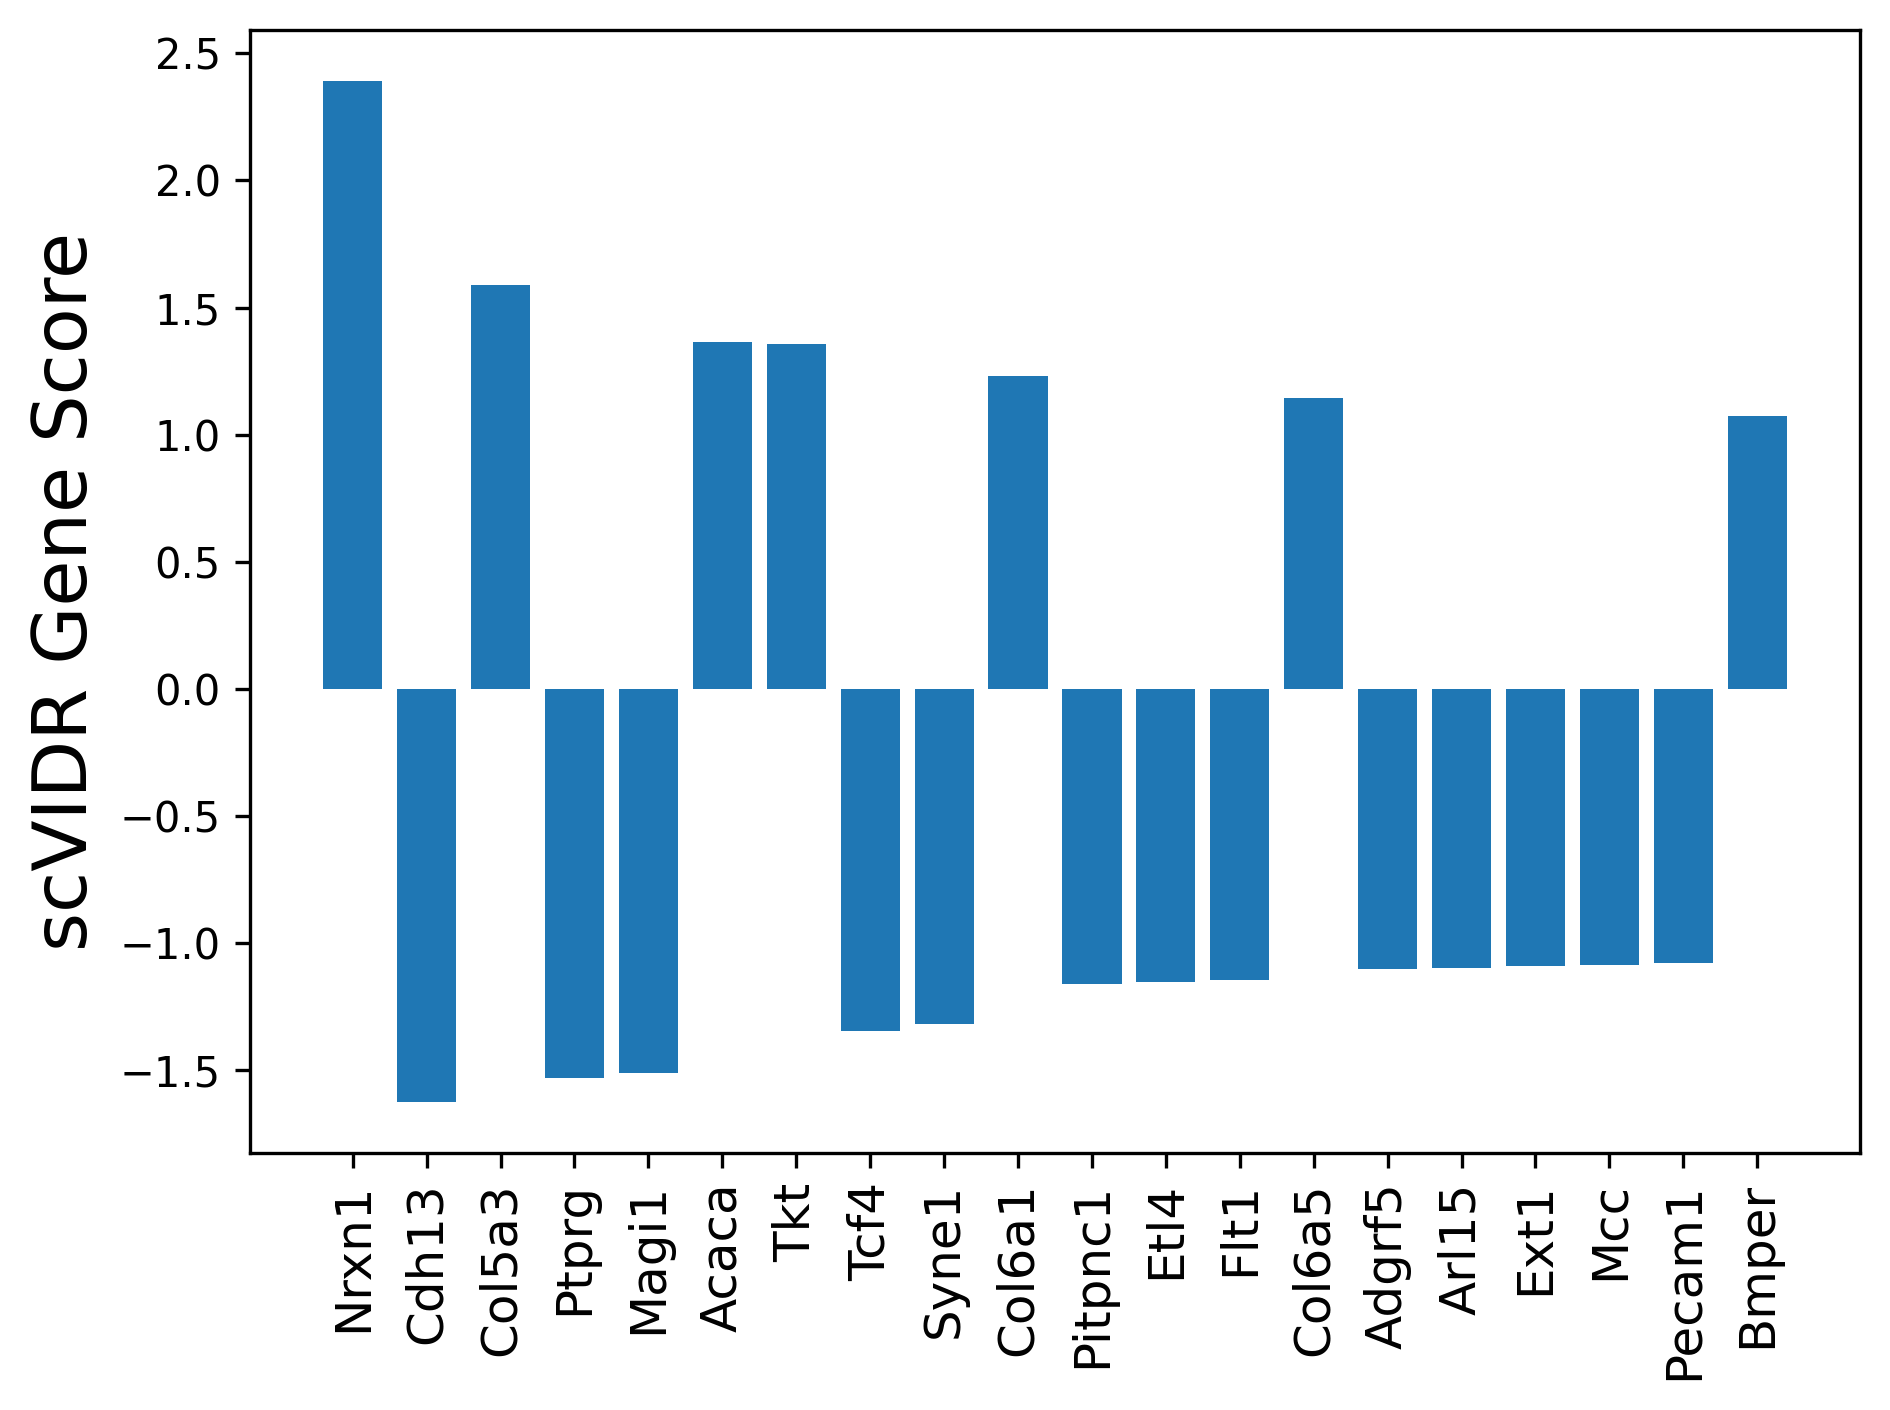

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the data


# Sort by absolute value of score
df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()
top_genes_df = df_Adipocytes_Brown.sort_values('abs_score', ascending=False).head(20)

# Plot
plt.figure(dpi=300)
plt.bar(top_genes_df['Gene'], top_genes_df['Score'])
plt.xticks(rotation=90, fontsize=12)
plt.ylabel(r"scVIDR Gene Score", fontsize=18)
plt.tight_layout()
#plt.savefig("../figures/4A.svg", bbox_inches="tight")
plt.show()


/usr/local/lib/python3.9/site-packages/gseapy/enrichr.py:409: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.results = self.results.append(res, ignore_index=True)


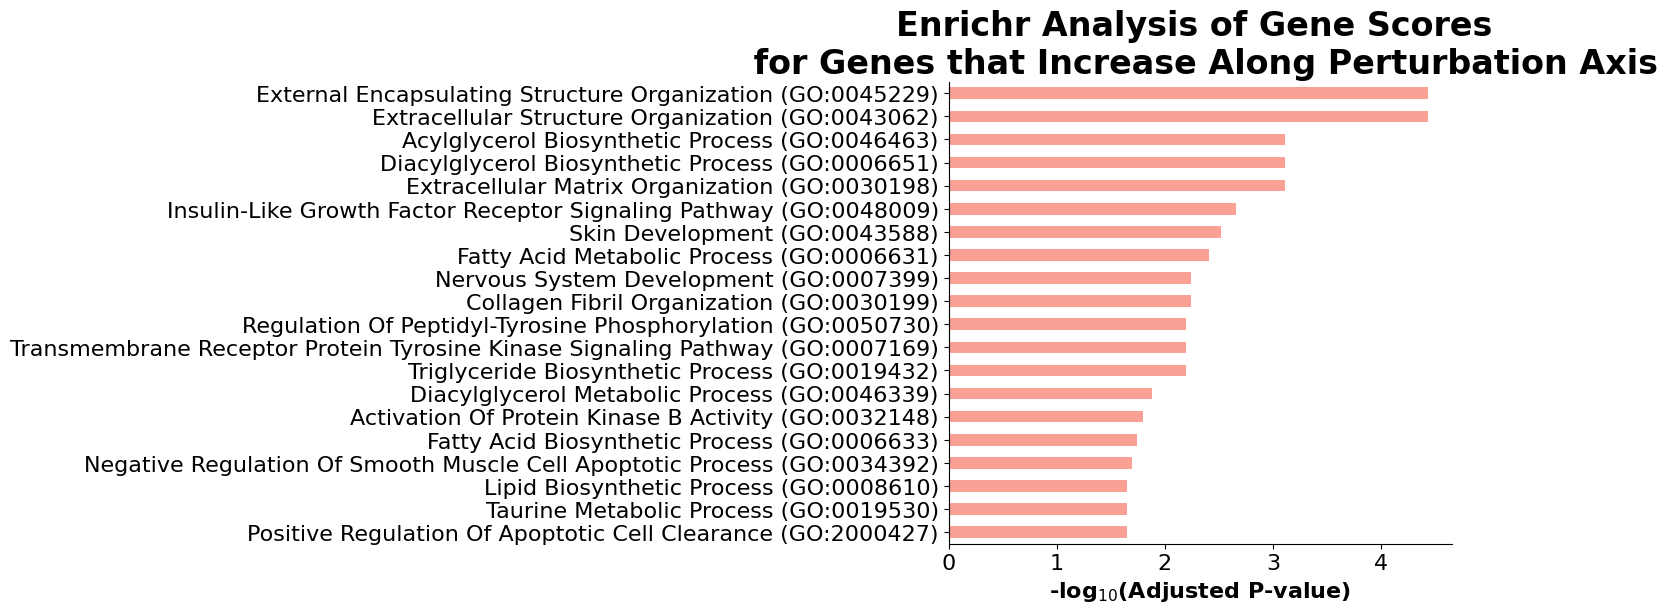

In [9]:
import gseapy as gp
import pandas as pd


# Rank by absolute score
df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()
top_genes = df_Adipocytes_Brown.sort_values('abs_score', ascending=False).head(100)

# Extract gene list
glist = top_genes['Gene'].tolist()

glist_top_increase = df_Adipocytes_Brown.sort_values('Score', ascending=False).head(100)
glist_top_increase = glist_top_increase['Gene'].tolist()
# Enrichment analysis
enr = gp.enrichr(
    gene_list=glist_top_increase,
    gene_sets= ["GO_Biological_Process_2023"], #["WikiPathways_2024_Mouse"],
    organism='Mouse',
    #description='adipocytes_brown_top100',
    #outdir='results/enrichr_adipocytes_brown',
    cutoff=0.5  # relaxed cutoff
)

gp.plot.barplot(enr.results,title='Enrichr Analysis of Gene Scores \n for Genes that Increase Along Perturbation Axis',fs = 8, top_term = 20)
#plt.savefig("../figures/4B.svg", bbox_inches = "tight")
# enr.results.head(10)

['Cdh13', 'Ptprg', 'Magi1', 'Tcf4', 'Syne1', 'Pitpnc1', 'Etl4', 'Flt1', 'Adgrf5', 'Arl15', 'Ext1', 'Mcc', 'Pecam1', 'Ptprm', 'LOC108352070', 'Plcb4', 'Heg1', 'Fbxl7', 'Arhgap31', 'Fryl', 'Flnb', 'Peak1', 'Rftn1', 'Shank3', 'Kalrn', 'Apbb2', 'Ptprb', 'Ccdc85a', 'Dst', 'Fli1', 'Eng', 'Mef2c', 'Tshz2', 'Magi3', 'Crim1', 'Lmo7', 'Cyyr1', 'Kitlg', 'Cmip', 'Map4', 'Akt3', 'Stard13', 'Ldb2', 'Etv6', 'Dock9', 'Mgll', 'Creb5', 'Stox2', 'Phactr2', 'Cald1', 'Egfl7', 'Slc8a1', 'Meox2', 'Smpd3', 'Dach1', 'Ldlrad4', 'Itpkb', 'St6galnac3', 'Prkch', 'Sptbn1', 'Rapgef1', 'Zeb1', 'Mast4', 'Dclk1', 'Rasal2', 'Mecom', 'Elmo1', 'Srgap2', 'Stxbp6', 'Myo1d', 'Myo10', 'Map4k3', 'Tanc1', 'Limch1', 'Sash1', 'LOC102550644', 'Plxna2', 'Fyn', 'Pdzd2', 'Cxcl12', 'Pkp4', 'Sh2d3c', 'Dgkh', 'Chn1', 'Gucy1a2', 'Sema6a', 'Myo1e', 'Lhfpl6', 'Notch1', 'Adamts5', 'AABR07028615.1', 'Dnm3', 'Cdh5', 'Sh3rf1', 'Arhgap18', 'Zbtb46', 'Cdk14', 'Sorbs2', 'Klf12', 'Fbn1']


/usr/local/lib/python3.9/site-packages/gseapy/enrichr.py:409: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.results = self.results.append(res, ignore_index=True)


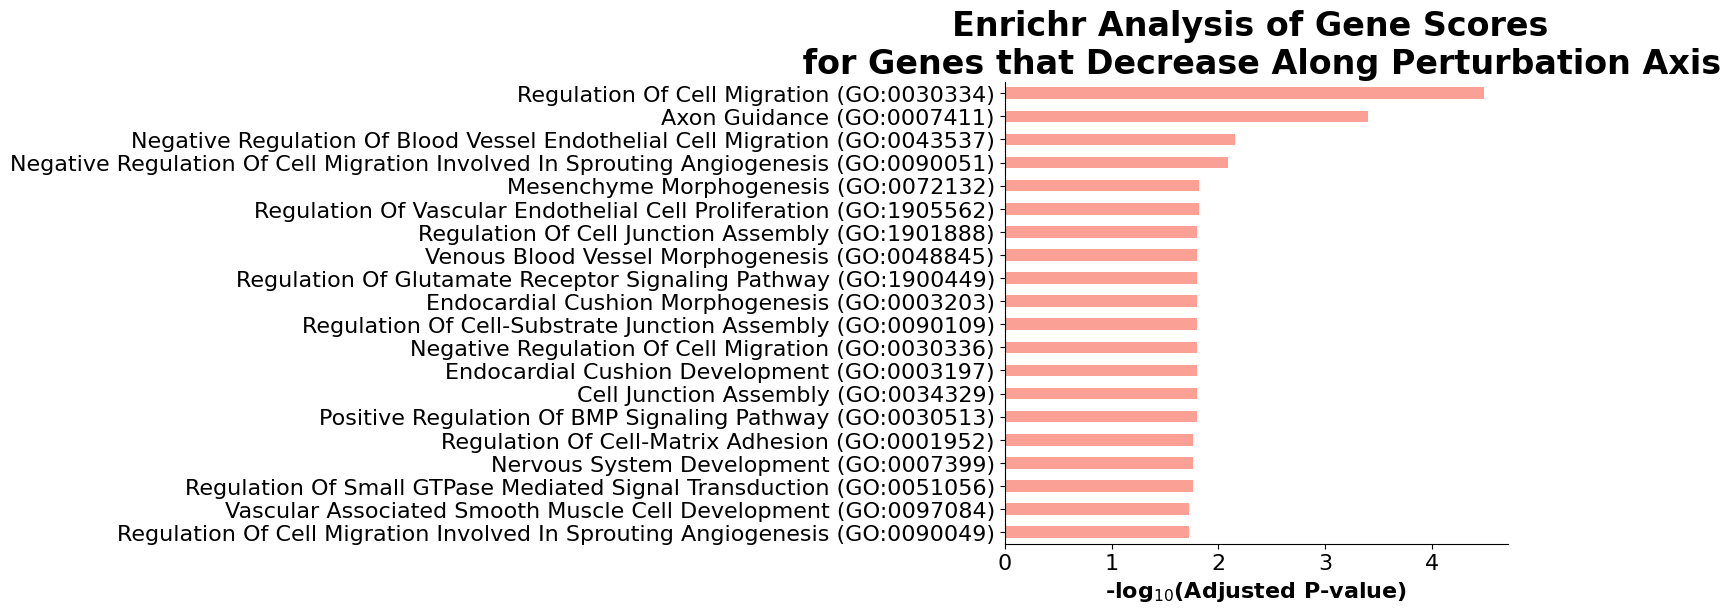

In [10]:
import gseapy as gp
import pandas as pd

# Load gene scores
df_Adipocytes_Brown = pd.read_csv('../predictions/gene_scores/gene_scores_Adipocytes_Brown_8W.csv')

# Rank by absolute score
df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()

glist_top_decrease = df_Adipocytes_Brown.sort_values('Score', ascending=True).head(100)
glist_top_decrease = glist_top_decrease['Gene'].tolist()

print(glist_top_decrease)
# Enrichment analysis
enr = gp.enrichr(
    gene_list=glist_top_decrease,
    gene_sets=["GO_Biological_Process_2023"], #["GO_Biological_Process_2023"],
    organism='Mouse',
    #description='adipocytes_brown_top100',
    #outdir='results/enrichr_adipocytes_brown',
    cutoff=0.5  # relaxed cutoff
)
enr.results.head(10)
gp.plot.barplot(enr.results,title='Enrichr Analysis of Gene Scores \n for Genes that Decrease Along Perturbation Axis',fs = 8, top_term = 20)
#plt.savefig("../figures/4B.svg", bbox_inches = "tight")




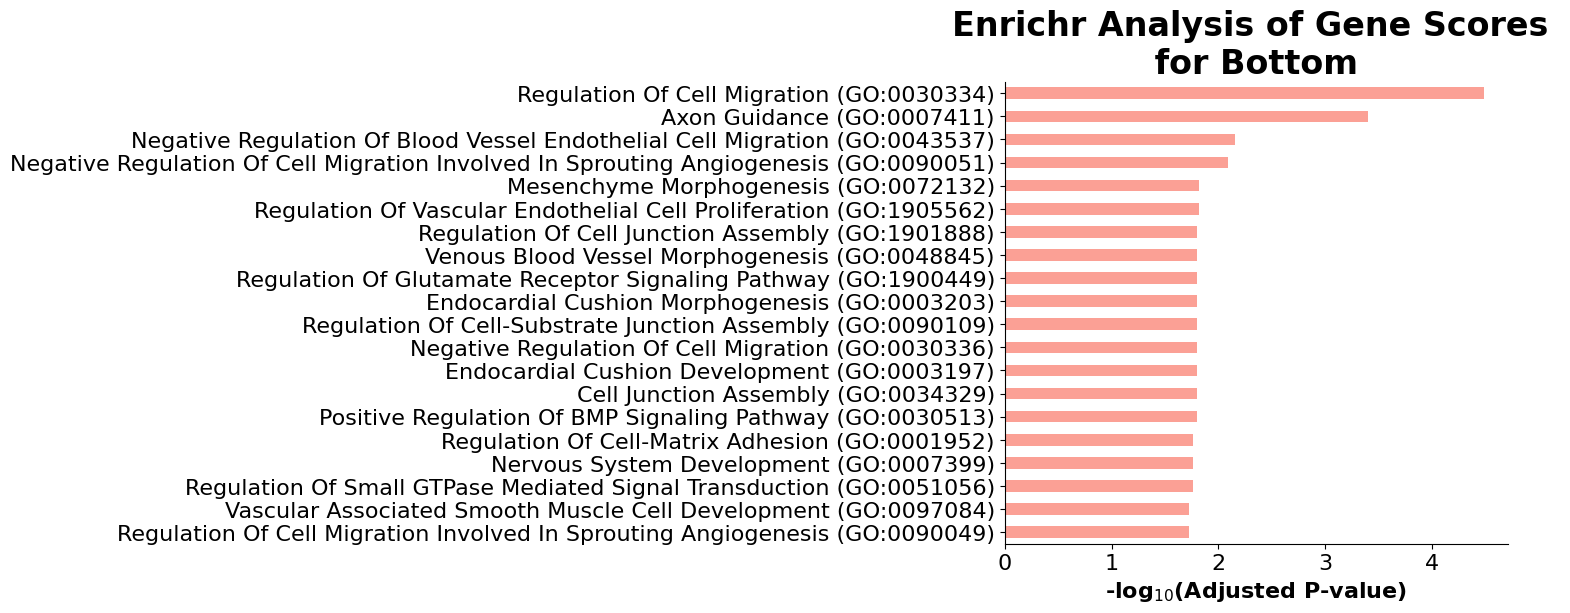

In [11]:
gp.plot.barplot(enr.results,title='Enrichr Analysis of Gene Scores \n for Bottom ',fs = 8, top_term = 20)

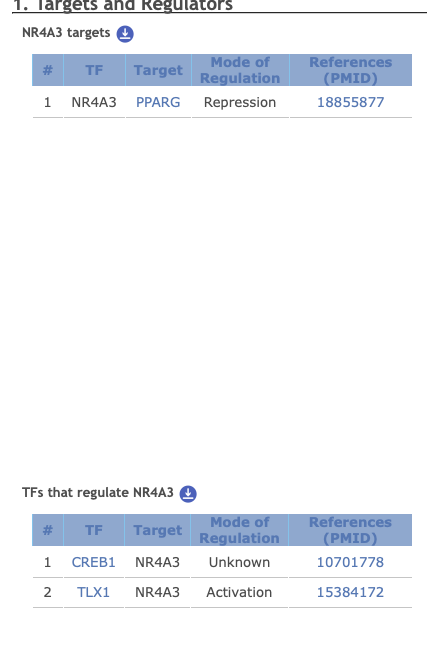

In [12]:
# 1	NR4A1	BABAM2	Repression	22159226
# 2	NR4A1	CCNA2	Repression	12842839
# 3	NR4A1	CDKN1B	Activation	12842839
# 4	NR4A1	CYP11A1	Unknown	20083153
# 5	NR4A1	CYP17A1	Unknown	20083153
# 6	NR4A1	E2F1	Activation	12947120
# 7	NR4A1	FASLG	Unknown	14563113
# 8	NR4A1	HSD3B2	Activation	15666793
# 9	NR4A1	HSD3B2	Unknown	15208301; 20083153; 23874725
# 10	NR4A1	MDM2	Repression	17139261
# 11	NR4A1	MMP2	Activation	22551568
# 12	NR4A1	RNF7	Repression	22159226
# 13	NR4A1	SERPINE1	Unknown	12506026
# 14	NR4A1	STAR	Unknown	20083153
# 15	NR4A1	TIMP2	Activation	22551568
# 16	NR4A1	TNF	Repression	19213954




### Regulators of NR4A1:
# TFs that regulate NR4A1  
# #	TF	Target	Mode of Regulation	References
# (PMID)
# 1	HDAC7	NR4A1	Unknown	15623513
# 2	HIF1A	NR4A1	Activation	14729605
# 3	MEF2C	NR4A1	Repression	18079734
# 4	PML	NR4A1	Repression	12032831
# 5	SP1	NR4A1	Unknown	8961265

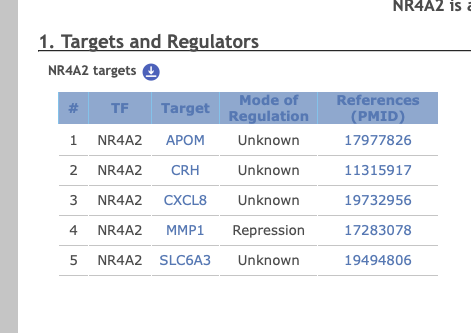

In [13]:
glist_top_increase

['Nrxn1',
 'Col5a3',
 'Acaca',
 'Tkt',
 'Col6a1',
 'Col6a5',
 'Bmper',
 'Pik3r1',
 'Txnip',
 'Igf1',
 'Ankef1',
 'Pnpla2',
 'Rgs6',
 'C4b',
 'Col4a1',
 'Abca8a',
 'Abi3bp',
 'Efna5',
 'Acly',
 'Zeb2',
 'Lrmda',
 'Ppargc1a',
 'Lsamp',
 'Col6a2',
 'Col3a1',
 'Rora',
 'Pde4d',
 'Col6a6',
 'C4a',
 'Gria4',
 'Agmo',
 'Kcnip4',
 'Pdzrn3',
 'Svep1',
 'Egfr',
 'Gk',
 'Lama2',
 'Ghr',
 'Fam13a',
 'Sytl5',
 'Adam12',
 'Ccdc80',
 'Peg3',
 'Map7d3',
 'Gpd1',
 'Apoo',
 'Syndig1',
 'Eya2',
 'Adamtsl1',
 'Fasn',
 'Pck1',
 'Rgs7',
 'Col6a3',
 'Ntrk3',
 'Nav3',
 'Sphkap',
 'Bcl2',
 'Zcchc24',
 'Cpt1b',
 'Gpm6a',
 'Hspg2',
 'Adcy5',
 'Kcnip1',
 'Cables1',
 'Kank1',
 'Acss3',
 'Me1',
 'Col1a1',
 'Adam19',
 'Lpin1',
 'Cacna2d3',
 'Fap',
 'Septin9',
 'Ddhd1',
 'Col5a1',
 'Car3',
 'Dgat2',
 'Aspg',
 'Ntf3',
 'Col4a2',
 'Zbtb16',
 'Srebf1',
 'Ppl',
 'Pappa',
 'Col15a1',
 'Cdo1',
 'Parm1',
 'Scd',
 'Ahnak',
 'Aox3',
 'LOC689800',
 'Bicc1',
 'Hs6st2',
 'Adam33',
 'Rpgr',
 'Rbms3',
 'Trhde',
 'Pkhd1l1',
 'Plce1